# Instrumental Variables — Returns to Education

Replicates Card (1995) using college proximity as an instrument for education
to estimate the causal effect of schooling on wages.

| | |
|---|---|
| **Treatment** | `educ` — years of education (continuous) |
| **Outcome** | `lwage` — log wages |
| **Instrument** | `nearc4` — grew up near a 4-year college (1/0) |

**Why IV?** People who get more education differ from those who don't in unobserved
ways — ability, motivation, family background. PSM can only control for observed
differences. The instrument (college proximity) creates quasi-random variation in
education that is unrelated to those unobserved factors.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

In [3]:
df = pd.read_csv(Path("../data/raw/card.csv"))

df = df.rename(columns={
    # --- Identifiers ---
    "id":       "person_id",

    # --- Instrument ---
    "nearc2":   "near_2yr_college_1966",   # grew up near a 2-year college in 1966
    "nearc4":   "near_4yr_college_1966",   # grew up near a 4-year college in 1966

    # --- Treatment & Outcome ---
    "educ":     "education_years",         # years of schooling (1976)
    "wage":     "hourly_wage_cents",       # hourly wage in cents (1976)
    "lwage":    "log_wage",                # log(hourly wage) — outcome

    # --- Demographics ---
    "age":      "age_years",
    "black":    "is_black",
    "married":  "is_married",

    # --- Family background ---
    "fatheduc": "father_education_years",
    "motheduc": "mother_education_years",
    "momdad14": "lived_with_both_parents_age14",
    "sinmom14": "single_mother_age14",
    "step14":   "step_parent_age14",
    "libcrd14": "library_card_at_home_age14",

    # --- Geography ---
    "smsa":     "lives_in_metro_area_1976",
    "smsa66":   "lived_in_metro_area_1966",
    "south":    "lives_in_south_1976",
    "south66":  "lived_in_south_1966",

    # --- Region dummies (1966) ---
    "reg661":   "region1_1966",
    "reg662":   "region2_1966",
    "reg663":   "region3_1966",
    "reg664":   "region4_1966",
    "reg665":   "region5_1966",
    "reg666":   "region6_1966",
    "reg667":   "region7_1966",
    "reg668":   "region8_1966",
    "reg669":   "region9_1966",

    # --- Labour market ---
    "exper":    "work_experience_years",   # age - education - 6
    "expersq":  "work_experience_sq",      # experience squared (for nonlinear returns)
    "enroll":   "enrolled_in_school_1976",
    "weight":   "sampling_weight",

    # --- Ability proxies ---
    "KWW":      "knowledge_work_score",    # Knowledge of the World of Work test
    "IQ":       "iq_score",
})

TREATMENT  = "education_years"
OUTCOME    = "log_wage"
INSTRUMENT = "near_4yr_college_1966"

print(f"Shape: {df.shape}")
df.head()

Shape: (3010, 34)


,person_id,near_2yr_college_1966,near_4yr_college_1966,education_years,age_years,father_education_years,mother_education_years,sampling_weight,lived_with_both_parents_age14,single_mother_age14,...,lived_in_metro_area_1966,hourly_wage_cents,enrolled_in_school_1976,knowledge_work_score,iq_score,is_married,library_card_at_home_age14,work_experience_years,log_wage,work_experience_sq
0,2,0,0,7,29,NaN,NaN,158413.0,1,0,...,1,548,0,15.0,NaN,1.0,0.0,16,6.306275,256
1,3,0,0,12,27,8.0,8.0,380166.0,1,0,...,1,481,0,35.0,93.0,1.0,1.0,9,6.175867,81
2,4,0,0,12,34,14.0,12.0,367470.0,1,0,...,1,721,0,42.0,103.0,1.0,1.0,16,6.580639,256
3,5,1,1,11,27,11.0,12.0,380166.0,1,0,...,1,250,0,25.0,88.0,1.0,1.0,10,5.521461,100
4,6,1,1,12,34,8.0,7.0,367470.0,1,0,...,1,729,0,34.0,108.0,1.0,0.0,16,6.591674,256


## review the data

<Axes: >

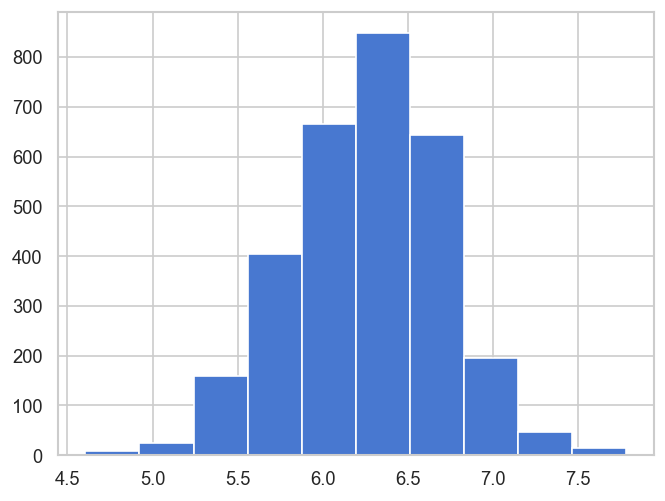

In [4]:
df[OUTCOME].hist()

<Axes: >

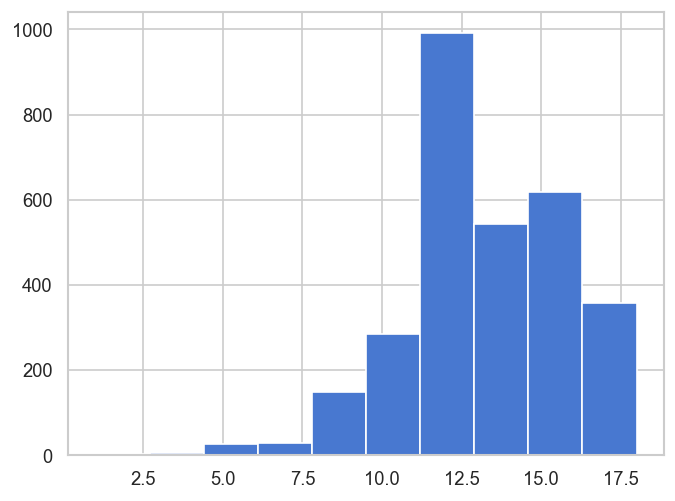

In [6]:
df[TREATMENT].hist()

## Relevance of the Instrument

In [10]:
df[df['near_4yr_college_1966'] == 1][TREATMENT].mean(), df[df['near_4yr_college_1966'] == 0][TREATMENT].mean()

(np.float64(13.527033609352168), np.float64(12.698014629049112))

In [11]:
df[df['near_4yr_college_1966'] == 1][OUTCOME].mean(), df[df['near_4yr_college_1966'] == 0][OUTCOME].mean()

(np.float64(6.311401214358055), np.float64(6.155493722315741))

## impact of education on s

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        education_years   R-squared:                       0.449
Model:                            OLS   Adj. R-squared:                  0.448
Method:                 Least Squares   F-statistic:                     488.7
Date:                Mon, 13 Jul 2026   Prob (F-statistic):               0.00
Time:                        07:35:19   Log-Likelihood:                -6338.6
No. Observations:                3010   AIC:                         1.269e+04
Df Residuals:                    3004   BIC:                         1.273e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                   14.8800      0.101    147.246      0.000      14.682      15.078
near_4yr_college_1966        0.3382      0.084      4.002      0.000       0.173       0.504
is_black                    -1.0518      0.092    -11.466      0.000      -1.232      -0.872
lives_in_metro_area_1976     0.4065      0.087      4.676      0.000       0.236       0.577
lives_in_south_1976         -0.2670      0.081     -3.291      0.001      -0.426      -0.108
work_experience_sq          -0.0187      0.000    -42.672      0.000      -0.020      -0.018
==============================================================================
Omnibus:                       38.650   Durbin-Watson:                   1.765
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               23.822
Skew:                           0.029   Prob(JB):                     6.72e-06
Kurtosis:                       2.568   Cond. No.                         436.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [22]:
formula = 'education_years ~ near_4yr_college_1966 '

model = smf.ols(formula, data=df).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        education_years   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     63.91
Date:                Mon, 13 Jul 2026   Prob (F-statistic):           1.84e-15
Time:                        07:35:22   Log-Likelihood:                -7202.7
No. Observations:                3010   AIC:                         1.441e+04
Df Residuals:                    3008   BIC:                         1.442e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                12.6980      0.086    148.269      0.000      12.530      12.866
near_4yr_college_1966     0.8290      0.104      7.994      0.000       0.626       1.032
==============================================================================
Omnibus:                       26.936   Durbin-Watson:                   1.626
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               28.373
Skew:                          -0.204   Prob(JB):                     6.90e-07
Kurtosis:                       3.243   Cond. No.                         3.31
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [26]:
formula = 'education_years ~ near_4yr_college_1966 + is_black + lives_in_metro_area_1976 + lives_in_south_1976 + work_experience_sq'

first_stage = smf.ols(formula, data=df).fit()
df['education_predicted'] = first_stage.fittedvalues

In [27]:
second_stage = smf.ols(
    'log_wage ~ education_predicted + is_black + lives_in_metro_area_1976 + lives_in_south_1976 + work_experience_years + work_experience_sq',
    data=df
).fit()

In [28]:
second_stage.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               log_wage   R-squared:                       0.187
Model:                            OLS   Adj. R-squared:                  0.185
Method:                 Least Squares   F-statistic:                     115.2
Date:                Mon, 13 Jul 2026   Prob (F-statistic):          3.59e-131
Time:                        10:24:22   Log-Likelihood:                -1513.5
No. Observations:                3010   AIC:                             3041.
Df Residuals:                    3003   BIC:                             3083.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                    3.9932      0.758      5.268      0.000       2.507       5.479
education_predicted          0.1319      0.050      2.623      0.009       0.033       0.231
is_black                    -0.1251      0.056     -2.226      0.026      -0.235      -0.015
lives_in_metro_area_1976     0.1311      0.031      4.239      0.000       0.070       0.192
lives_in_south_1976         -0.1082      0.023     -4.763      0.000      -0.153      -0.064
work_experience_years        0.0533      0.007      7.666      0.000       0.040       0.067
work_experience_sq           0.0003      0.001      0.276      0.783      -0.002       0.002
==============================================================================
Omnibus:                       35.187   Durbin-Watson:                   1.829
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               40.706
Skew:                          -0.205   Prob(JB):                     1.45e-09
Kurtosis:                       3.396   Cond. No.                     1.34e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.34e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [29]:
smf.ols(
    'log_wage ~ education_years + is_black + lives_in_metro_area_1976 + lives_in_south_1976 + work_experience_years + work_experience_sq',
    data=df
).fit().params['education_years']


np.float64(0.07400899420057766)

In [ ]:
ols_coef = smf.ols(
    'log_wage ~ education_years + is_black + lives_in_metro_area_1976 + lives_in_south_1976 + work_experience_years + work_experience_sq',
    data=df
).fit().params['education_years']

iv_coef = second_stage.params['education_predicted']

print("=" * 45)
print("  Returns to Education — OLS vs IV (2SLS)")
print("=" * 45)
print(f"  OLS estimate : {ols_coef:.3f}  ({ols_coef*100:.1f}% per year)")
print(f"  IV estimate  : {iv_coef:.3f}  ({iv_coef*100:.1f}% per year)")
print(f"  OLS bias     : {iv_coef - ols_coef:.3f}  ({(iv_coef/ols_coef - 1)*100:.0f}% underestimate)")
print("=" * 45)
print()
print("OLS understates the return to education because")
print("people who get less schooling are negatively")
print("selected on unobserved ability — IV corrects this")
print("by using only the variation in education caused")
print("by geographic proximity to college.")